# CH06_Probability

---
## 6.1: Probability
---

### 6.1.1: Frequentist versus Bayesian

### 6.1.2: Definition and Axioms

### 6.1.3: Permutations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from math import comb, exp, factorial, log, perm

os.chdir('/home/user/repo/studies/qss/data')

In [2]:
def birthday(k):
    logdenom = k * log(365) + log(factorial(365 - k))
    lognumer = log(factorial(365))
    pr = 1 - exp(lognumer - logdenom)
    return pr

In [3]:
k = pd.Series(np.arange(1,51))

bday = k.apply(birthday)
bday.index = k

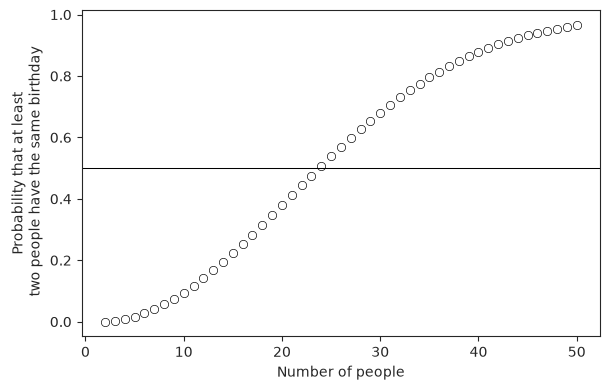

In [5]:
sns.set_style('ticks')

sns.relplot(
    x=k, y=bday, color='white', edgecolor='black', height=4, aspect=1.5
).set(ylabel='Probability that at least\n two people have the same birthday',
      xlabel='Number of people').despine(right=False, top=False)

plt.axhline(0.5, color='black', linewidth=.75);

In [7]:
bday[20:25]

21    0.443688
22    0.475695
23    0.507297
24    0.538344
25    0.568700
dtype: float64

### 6.1.4: Sampling With and Without Replacement

In [8]:
k = 23
sims = 10000
event = 0

for i in range(sims):
    days = np.random.choice(np.arange(1,366), size=k, replace=True)
    days_unique = np.unique(days)

    if len(days_unique) < len(days):
        event += 1

answer = event / sims
answer

0.5055

### 6.1.5: Combinations

In [18]:
comb(20,5)

15504

In [19]:
comb(10,0)

1

In [20]:
comb(10,5)

252

In [21]:
252/15504

0.016253869969040248

In [23]:
comb(10,1) * comb(10,4) / comb(20,5)

0.13544891640866874

In [24]:
1 - (comb(10,0) * comb(10,5) / comb(20,5)) - (comb(10,1) * comb(10,4) / comb(20,5))

0.848297213622291

In [26]:
comb(84,6)

406481544

In [27]:
12 / comb(84,6)

2.952163555056758e-08

---
## 6.2: Conditional Probability
---

### 6.2.1: Conditional, Marginal, and Joint Probabilities

In [2]:
FLVoters = pd.read_csv('FLVoters.csv')
FLVoters.shape

(10000, 6)

In [3]:
FLVoters.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   surname  9999 non-null   str    
 1   county   10000 non-null  int64  
 2   VTD      10000 non-null  int64  
 3   age      9992 non-null   float64
 4   gender   9992 non-null   str    
 5   race     9126 non-null   str    
dtypes: float64(1), int64(2), str(3)
memory usage: 468.9 KB


In [4]:
FLVoters[FLVoters['surname'].isnull()]

,surname,county,VTD,age,gender,race
349,NaN,5,14,70.0,f,white


In [5]:
FLVoters.head()

,surname,county,VTD,age,gender,race
0,PIEDRA,115,66,58.0,f,white
1,LYNCH,115,13,51.0,m,white
2,CHESTER,115,103,63.0,m,NaN
3,LATHROP,115,80,54.0,m,white
4,HUMMEL,115,8,77.0,f,white


In [6]:
FLVoters['surname'] = np.where(
    FLVoters['surname'].isnull(), 'NULL', FLVoters['surname'])

In [7]:
FLVoters.loc[[349]]

,surname,county,VTD,age,gender,race
349,NULL,5,14,70.0,f,white


In [8]:
FLVoters = FLVoters.dropna()
FLVoters.shape

(9113, 6)

In [9]:
margin_race = FLVoters['race'].value_counts(normalize=True).sort_index()
margin_race

race
asian       0.019203
black       0.131022
hispanic    0.130802
native      0.003182
other       0.034017
white       0.681773
Name: proportion, dtype: float64

In [10]:
margin_gender = FLVoters['gender'].value_counts(normalize=True).sort_index()
margin_gender

gender
f    0.535828
m    0.464172
Name: proportion, dtype: float64

In [11]:
FLVoters.loc[FLVoters.gender == 'f', 'race'].value_counts(normalize=True).sort_index()

race
asian       0.016998
black       0.138849
hispanic    0.136392
native      0.003481
other       0.032357
white       0.671923
Name: proportion, dtype: float64

In [12]:
joint_p = pd.crosstab(FLVoters.race, FLVoters.gender, normalize=True)
joint_p

gender,f,m
race,,
asian,0.009108,0.010095
black,0.074399,0.056622
hispanic,0.073082,0.057720
native,0.001865,0.001317
other,0.017338,0.016679
white,0.360035,0.321738


In [13]:
joint_p.sum(axis=1)

race
asian       0.019203
black       0.131022
hispanic    0.130802
native      0.003182
other       0.034017
white       0.681773
dtype: float64

In [14]:
joint_p.sum()

gender
f    0.535828
m    0.464172
dtype: float64

In [15]:
pd.crosstab(FLVoters.race, FLVoters.gender, normalize=True, margins=True)

gender,f,m,All
race,,,
asian,0.009108,0.010095,0.019203
black,0.074399,0.056622,0.131022
hispanic,0.073082,0.057720,0.130802
native,0.001865,0.001317,0.003182
other,0.017338,0.016679,0.034017
white,0.360035,0.321738,0.681773
All,0.535828,0.464172,1.000000


In [16]:
conditions = [
    (FLVoters.age <= 20),
    (FLVoters.age > 20) & (FLVoters.age <= 40),
    (FLVoters.age > 40) & (FLVoters.age <= 60)
]

choice = [1, 2, 3]

FLVoters['age_group'] = np.select(conditions, choice, 4)

In [17]:
joint3 = pd.crosstab([FLVoters.race, FLVoters.age_group], FLVoters.gender, normalize=True)
joint3

gender                     f         m
race     age_group                    
asian    1          0.000110  0.000219
         2          0.002634  0.002853
         3          0.004170  0.005157
         4          0.002195  0.001865
black    1          0.001646  0.001646
         2          0.028092  0.022825
         3          0.025787  0.018984
         4          0.018874  0.013168
hispanic 1          0.001536  0.001646
         2          0.026007  0.019752
         3          0.027324  0.022166
         4          0.018216  0.014156
native   1          0.000110  0.000000
         2          0.000439  0.000439
         3          0.000658  0.000329
         4          0.000658  0.000549
other    1          0.000329  0.000439
         2          0.006255  0.006913
         3          0.005816  0.005596
         4          0.004938  0.003731
white    1          0.005926  0.004060
         2          0.079666  0.075058
         3          0.126084  0.118402
         4          0.148359  0.124218

In [18]:
pd.crosstab([FLVoters.race, FLVoters.age_group], FLVoters.gender, normalize=True, margins=True)

gender                     f         m       All
race     age_group                              
asian    1          0.000110  0.000219  0.000329
         2          0.002634  0.002853  0.005487
         3          0.004170  0.005157  0.009327
         4          0.002195  0.001865  0.004060
black    1          0.001646  0.001646  0.003292
         2          0.028092  0.022825  0.050916
         3          0.025787  0.018984  0.044771
         4          0.018874  0.013168  0.032042
hispanic 1          0.001536  0.001646  0.003182
         2          0.026007  0.019752  0.045759
         3          0.027324  0.022166  0.049490
         4          0.018216  0.014156  0.032371
native   1          0.000110  0.000000  0.000110
         2          0.000439  0.000439  0.000878
         3          0.000658  0.000329  0.000988
         4          0.000658  0.000549  0.001207
other    1          0.000329  0.000439  0.000768
         2          0.006255  0.006913  0.013168
         3          0.005816  0.005596  0.011412
         4          0.004938  0.003731  0.008669
white    1          0.005926  0.004060  0.009986
         2          0.079666  0.075058  0.154724
         3          0.126084  0.118402  0.244486
         4          0.148359  0.124218  0.272578
All                 0.535828  0.464172  1.000000

In [19]:
margin_age = FLVoters['age_group'].value_counts(normalize=True).sort_index()
margin_age

age_group
1    0.017667
2    0.270932
3    0.360474
4    0.350927
Name: proportion, dtype: float64

In [20]:
joint3.index[:3]

MultiIndex([('asian', 1),
            ('asian', 2),
            ('asian', 3)],
           names=['race', 'age_group'])

In [21]:
joint3.loc[('black', 4), 'f'] / margin_age[4]

np.float64(0.05378361475922452)

In [22]:
joint2 = pd.crosstab(FLVoters['age_group'], FLVoters['gender'], normalize=True, margins=True)
joint2

gender,f,m,All
age_group,,,
1,0.009657,0.008011,0.017667
2,0.143092,0.127839,0.270932
3,0.189839,0.170635,0.360474
4,0.193240,0.157687,0.350927
All,0.535828,0.464172,1.000000


In [23]:
joint2.loc[4,'f']

np.float64(0.1932404257653901)

In [24]:
0.018874 / 0.193240

0.097671289588077

In [25]:
joint3.loc[('black', 4), 'f'] / joint2.loc[4, 'f']

np.float64(0.097671777399205)

### 6.2.2: Independence

In [26]:
margin_race

race
asian       0.019203
black       0.131022
hispanic    0.130802
native      0.003182
other       0.034017
white       0.681773
Name: proportion, dtype: float64

In [27]:
margin_gender

gender
f    0.535828
m    0.464172
Name: proportion, dtype: float64

In [28]:
joint_p

gender,f,m
race,,
asian,0.009108,0.010095
black,0.074399,0.056622
hispanic,0.073082,0.057720
native,0.001865,0.001317
other,0.017338,0.016679
white,0.360035,0.321738


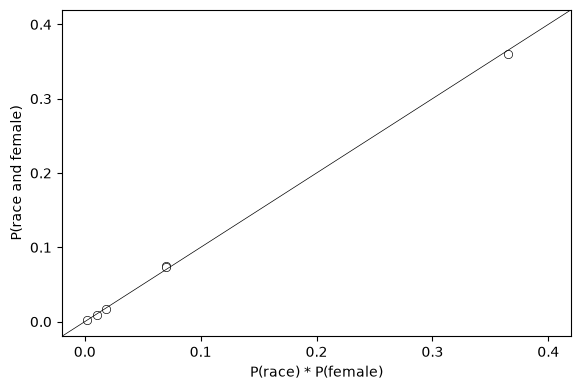

In [29]:
lims = (-0.02, 0.42)
ticks = [0, .1, .2, .3, .4]

sns.relplot(
    x=margin_race * margin_gender['f'], y=joint_p['f'],
    color='white', edgecolor='black', height=4, aspect=1.5
).set(xlabel='P(race) * P(female)', ylabel='P(race and female)',
      xlim=lims, ylim=lims, xticks=ticks, yticks=ticks).despine(right=False, top=False)

plt.gca().axline((0,0), slope=1, color='black', linewidth=.5);

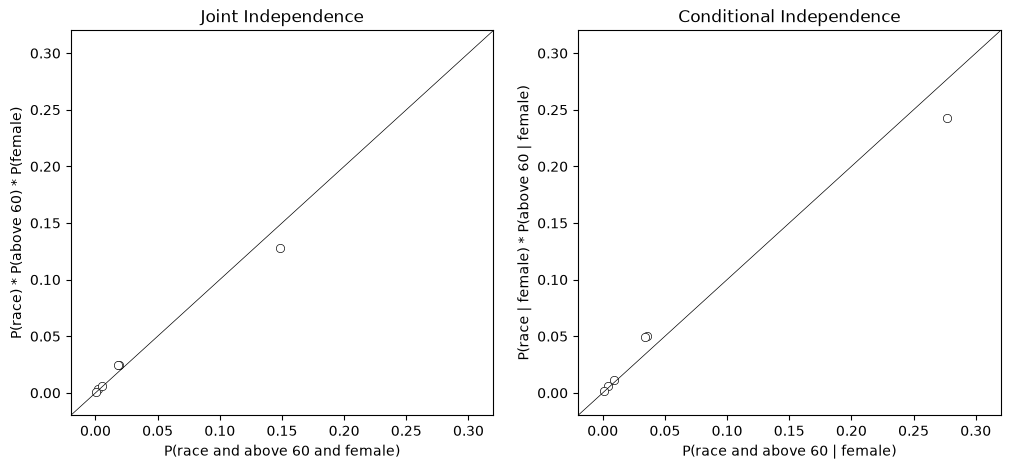

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(12,5))

lims = (-0.02, 0.32)

sns.scatterplot(
    x=joint3.loc[(slice(None), 4), 'f'].droplevel('age_group'),
    y=margin_race * margin_age[4] * margin_gender['f'],
    color='white', edgecolor='black', ax=axs[0]
).set(xlabel='P(race and above 60 and female)', 
      ylabel='P(race) * P(above 60) * P(female)',
      title='Joint Independence', xlim=lims, ylim=lims)

axs[0].axline((0,0), slope=1, color='black', linewidth=.5)

sns.scatterplot(
    x=(joint3.loc[(slice(None), 4), 'f'] / margin_gender['f']).droplevel('age_group'),
    y=((joint_p['f'] / margin_gender['f']) * (joint2.loc[4, 'f'] / margin_gender['f'])),
    color='white', edgecolor='black', ax=axs[1]
).set(xlabel='P(race and above 60 | female)', 
      ylabel='P(race | female) * P(above 60 | female)',
      title='Conditional Independence', xlim=lims, ylim=lims)

axs[1].axline((0,0), slope=1, color='black', linewidth=.5)

In [31]:
sims = 1000
doors = np.array(['goat', 'goat', 'car'])

result_switch = np.empty(sims, dtype=doors.dtype)
result_noswitch = np.empty(sims, dtype=doors.dtype)

In [32]:
for i in range(sims):
    # randomly choose the initial door
    first = np.random.choice(np.arange(0,3))
    result_noswitch[i] = doors[first]
    remain = np.delete(doors, first) # remaining two doors
    if doors[first] == 'car': # two goats left
        monty = np.random.choice(np.arange(0,2))
    else: # one goat and one car left
        monty = np.arange(0,2)[remain=='goat']
    result_switch[i] = np.delete(remain, monty)[0]

In [33]:
(result_noswitch == 'car').mean()

np.float64(0.325)

In [34]:
(result_switch == 'car').mean()

np.float64(0.675)

### 6.2.3: Bayes' Rule

### 6.2.4: Predicting Race Using Surname and Residence Location

In [35]:
cnames = pd.read_csv('names.csv')
cnames.info()

<class 'pandas.DataFrame'>
RangeIndex: 151671 entries, 0 to 151670
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   surname      151670 non-null  str    
 1   count        151671 non-null  int64  
 2   pctwhite     151671 non-null  float64
 3   pctblack     151671 non-null  float64
 4   pctapi       151671 non-null  float64
 5   pcthispanic  151671 non-null  float64
 6   pctothers    151671 non-null  float64
dtypes: float64(5), int64(1), str(1)
memory usage: 8.1 MB


In [36]:
cnames['surname'] = np.where(
    cnames['surname'].isnull(), 'NULL', cnames['surname']
)

In [37]:
cnames.shape

(151671, 7)

In [38]:
cnames.head()

,surname,count,pctwhite,pctblack,pctapi,pcthispanic,pctothers
0,SMITH,2376206,73.342666,22.217778,0.399960,1.559844,2.479752
1,JOHNSON,1857160,61.550000,33.800000,0.420000,1.500000,2.730000
2,WILLIAMS,1534042,48.520000,46.720000,0.370000,1.600000,2.790000
3,BROWN,1380145,60.716072,34.543454,0.410041,1.640164,2.690269
4,JONES,1362755,57.690000,37.730000,0.350000,1.440000,2.790000


In [39]:
FLVoters.shape

(9113, 7)

In [40]:
FLVoters = pd.merge(FLVoters, cnames, on='surname')
FLVoters.shape

(8022, 13)

In [41]:
FLVoters.head()

,surname,county,VTD,age,gender,race,age_group,count,pctwhite,pctblack,pctapi,pcthispanic,pctothers
0,PIEDRA,115,66,58.0,f,white,3,3518,6.710000,1.190000,0.430000,91.390000,0.280000
1,LYNCH,115,13,51.0,m,white,3,114448,84.220000,11.230000,0.430000,1.680000,2.440000
2,LATHROP,115,80,54.0,m,white,3,7936,93.390661,1.779822,0.779922,1.879812,2.169783
3,HUMMEL,115,8,77.0,f,white,4,14878,97.210000,0.130000,0.470000,1.220000,0.970000
4,CHRISTISON,115,55,49.0,m,white,3,812,95.570000,0.310000,1.350000,0.860000,1.910000


In [42]:
vars = ["pctwhite", "pctblack", "pctapi", "pcthispanic", "pctothers"]

In [44]:
whites = FLVoters.loc[FLVoters.race == 'white'].copy()

In [49]:
(whites[vars].max(axis='columns') == whites['pctwhite']).mean()

np.float64(0.950218023255814)

In [52]:
blacks = FLVoters.loc[FLVoters.race == 'black'].copy()
(blacks[vars].max(axis='columns') == blacks['pctblack']).mean()

np.float64(0.16048237476808905)

In [ ]:
hispanics = FLVoters.loc[FLVoters.race == 'hispanic'].copy()
(hispanics[vars].max(axis='columns') == hispanics['pcthispanic']).mean()

np.float64(0.8465298142717498)

In [ ]:
asians = FLVoters.loc[FLVoters.race == 'asian'].copy()
(asians[vars].max(axis='columns') == asians['pctapi']).mean()

np.float64(0.5642857142857143)

In [61]:
1 - (FLVoters.loc[FLVoters[vars].max(axis=1) == FLVoters.pctwhite, 'race'] == 'white').mean()

np.float64(0.19736034376918354)

In [62]:
1 - (FLVoters.loc[FLVoters[vars].max(axis=1) == FLVoters.pctblack, 'race'] == 'black').mean()

np.float64(0.3294573643410853)

In [63]:
1 - (FLVoters.loc[FLVoters[vars].max(axis=1) == FLVoters.pcthispanic, 'race'] == 'hispanic').mean()

np.float64(0.22747546833184662)

In [64]:
1 - (FLVoters.loc[FLVoters[vars].max(axis=1) == FLVoters.pctapi, 'race'] == 'asian').mean()

np.float64(0.3416666666666667)

In [65]:
FLCensus = pd.read_csv('FLCensusVTD.csv')

# compute proportions by applying np.average to each column with pop weight
census_race = ['white', 'black', 'api', 'hispanic', 'others']

race_prop = FLCensus[census_race].apply(
    lambda x: np.average(x, weights=FLCensus['total.pop']))

race_prop # race proportions in Florida

white       0.578934
black       0.151644
api         0.024197
hispanic    0.224655
others      0.020570
dtype: float64

In [66]:
# store total count from original cnames data
total_count = cnames['count'].sum()

# P(surname | race) = P(race | surname) * P(surname) / P(race) in Florida
FLVoters['name_white'] = (
       (FLVoters['pctwhite'] / 100) * (FLVoters['count'] / total_count) /
       race_prop['white'])

FLVoters['name_black'] = (
       (FLVoters['pctblack'] / 100) * (FLVoters['count'] / total_count) /
       race_prop['black'])

FLVoters['name_hispanic'] = (
       (FLVoters['pcthispanic'] / 100) * (FLVoters['count'] / total_count) /
       race_prop['hispanic'])

FLVoters['name_asian'] = (
       (FLVoters['pctapi'] / 100) * (FLVoters['count'] / total_count) /
       race_prop['api'])

FLVoters['name_others'] = (
       (FLVoters['pctothers'] / 100) * (FLVoters['count'] / total_count) /
       race_prop['others'])

In [67]:
# merge FLVoters with FLCensus by county and VTD using left join
FLVoters = pd.merge(FLVoters, FLCensus, on=['county', 'VTD'], how='left')

# P(surname | residence) = sum_race P(surname | race) P(race | residence)
FLVoters['name_residence'] = (
    FLVoters['name_white'] * FLVoters['white'] + 
    FLVoters['name_black'] * FLVoters['black'] + 
    FLVoters['name_hispanic'] * FLVoters['hispanic'] + 
    FLVoters['name_asian'] * FLVoters['api'] + 
    FLVoters['name_others'] * FLVoters['others'])

In [68]:
'''
P(race | surname, residence) = P(surname | race) * P(race | residence) /
P(surname | residence)
'''

FLVoters['pre_white'] = (FLVoters.name_white * FLVoters.white / 
                         FLVoters.name_residence)

FLVoters['pre_black'] = (FLVoters.name_black * FLVoters.black /
                         FLVoters.name_residence)

FLVoters['pre_hispanic'] = (FLVoters.name_hispanic * FLVoters.hispanic /
                            FLVoters.name_residence)

FLVoters['pre_asian'] = (FLVoters.name_asian * FLVoters.api /
                         FLVoters.name_residence)

FLVoters['pre_others'] = (1 - FLVoters.pre_white - FLVoters.pre_black -
                          FLVoters.pre_hispanic - FLVoters.pre_asian)

In [69]:
# relevant variables
vars1 = ['pre_white', 'pre_black', 'pre_hispanic', 'pre_asian', 'pre_others']

# Whites 
whites = FLVoters.loc[FLVoters.race == 'white'].copy()
(whites[vars1].max(axis='columns') == whites['pre_white']).mean()

np.float64(0.9418604651162791)

In [70]:
# Blacks
blacks = FLVoters.loc[FLVoters.race == 'black'].copy()
(blacks[vars1].max(axis='columns') == blacks['pre_black']).mean()

np.float64(0.62708719851577)

In [71]:
# Hispanics
hispanics = FLVoters.loc[FLVoters.race == 'hispanic'].copy()
(hispanics[vars1].max(axis='columns') == hispanics['pre_hispanic']).mean()

np.float64(0.8572825024437928)

In [72]:
# Asians
asians = FLVoters.loc[FLVoters.race == 'asian'].copy()
(asians[vars1].max(axis='columns') == asians['pre_asian']).mean()

np.float64(0.6071428571428571)

In [73]:
# proportion of blacks among those with surname "White"
cnames['pctblack'][cnames.surname == "WHITE"]

19    27.38
Name: pctblack, dtype: float64

In [74]:
# predicted probability of being black given residence location 
FLVoters['pre_black'][FLVoters.surname == "WHITE"].describe()

count    24.000000
mean      0.250711
std       0.293894
min       0.004588
25%       0.072232
50%       0.159496
75%       0.293640
max       0.981864
Name: pre_black, dtype: float64

In [75]:
1 - (FLVoters['race'][FLVoters[vars1].max(axis='columns') == 
                      FLVoters['pre_white']] == "white").mean()

np.float64(0.12239715591670897)

In [76]:
# Blacks
1 - (FLVoters['race'][FLVoters[vars1].max(axis='columns') == 
                      FLVoters['pre_black']] == "black").mean()

np.float64(0.22029988465974626)

In [77]:
# Hispanics
1 - (FLVoters['race'][FLVoters[vars1].max(axis='columns') == 
                      FLVoters['pre_hispanic']] == "hispanic").mean()

np.float64(0.21133093525179858)

In [78]:
# Asians
1 - (FLVoters['race'][FLVoters[vars1].max(axis='columns') == 
                      FLVoters['pre_asian']] == "asian").mean()

np.float64(0.3307086614173228)

---
## 6.3: Random Variables and Probability Distributions
---